# Working with Robots

This notebook introduces the robot workflow in RobotBlockSet. Its purpose is to show how to create, configure, inspect, and operate robots through a common interface.


## What this notebook covers

The examples below demonstrate the typical steps for working with robots, including imports, robot creation, access to robot state, motion commands, kinematics, and simulation or visualization support.

Use this notebook as a practical starting point for understanding the robot API and for adapting the workflow to your own robot model, controller, or experimental setup.


# Imports


In [1]:
import numpy as np
import scipy.io
import matplotlib.pyplot as plt
from datetime import datetime

from robotblockset.tools import get_rbs_path
from robotblockset.mujoco.robots_pymujoco import mujoco_scene, panda
from robotblockset.transformations import *
from robotblockset.trajectories import *
from robotblockset.robots import MotionResultStr


np.set_printoptions(formatter={"float": "{: 0.4f}".format})

# Robot objects

The essential part of the RBS is to provide robot classes to control different robots in the same manner. To achieve this, we have defined  a master robot class where all general properties and methods needed to control a robot are defined

- motion generation methods,
- kinematic controllers,
- transformation functions between different representations of robots states, 
- transformation functions between different spaces, 
- utility functions, etc.

In RBS we support in general four task coordinate systems:

| Space      | Description                                                  |
| ---------- | ------------------------------------------------------------ |
| `'World'`  | Cartesian space                                              |
| `'Robot'`  | Cartesian space with origin in the robot base defined by property `<robot>.TBase` |
| `'Object'` | Custom defined cartesian space defined by `<robot>.TObject`  |
| `'Tool'`   | Cartesian space aligned with robot end-effector              |

In the implementation classes all specific functionalities of a robots and their interfaces are considered. Additionally, the implementation classes define all abstract methods defined in master class and can redefine some already defined methods to adapt them to special requirements of a particular robot.

To be able to control the motion of a robot we use in RBS kinematic models of robot manipulators. Kinematic models can be generated using the Denavit-Hartenberg (DH) notation or the model is imported from the URDF file describing the robot.


# Creation of a robot object

The creation of a robot object depends on the target backend. In this tutorial we use for backend the MuJoCo simulator with Python bindings. First we have to open the scene with a robot.

In [2]:
MODEL_PATH = get_rbs_path() + "/mujoco/mjcf_models/panda_wall_scene.xml"
scene = mujoco_scene(MODEL_PATH, show_camera=None, synchronized=True, verbose=1)

To create a Panda robot object which will be connected to a MuJoCo simulator we use the following command

In [3]:
r = panda(scene=scene)

[RBS_INFO] [07:29:33] [panda_PyMuJoCo]: Robot connected to MuJoCo


> ⚠️ **Note:**  We can define during creation some optional parameters by adding `name=value` input parameters to the above commands. 

## TCP

After definig a robot, it is common to define the TCP of the robot, i.e. the transformation between the roboto flange and operational point on the end-effector. TCP related methods ara:

| Method            | Description                      |
| ----------------- | -------------------------------- |
| `r.SetTCP(tcp, frame="Gripper")` | Sets the tool center point |
| `r.GetTCP(out="T")`     | Get robot TCP relative to flange |

with optional parameter

| Option       | Value                     | Comment                                                 |
| ------------ | ------------------------- | ------------------------------------------------------- |
| `frame` | `"Gripper"`,<br>`"Flange"` | TCP is relative to gripper<br>TCP is relative to flange |


> ⚠️ **Note:**  The option `frame="Gripper"` uses robot internal transformation `TCPGripper` which defines the transformation between the robot flange and the gripper operational point.

For example,


In [4]:
r.SetTCP([0, 0, 0.1], frame="Flange")  # TCP is relative to flange
print(r.GetTCP(out="T"))

[[ 1.0000  0.0000  0.0000  0.0000]
 [ 0.0000  1.0000  0.0000  0.0000]
 [ 0.0000  0.0000  1.0000  0.1000]
 [ 0.0000  0.0000  0.0000  1.0000]]


or

In [5]:
r.SetTCP([0, 0, 0.1], frame="Gripper")  # TCP is relative to gripper
print(r.GetTCP(out="T"))

[[ 0.7071  0.7071  0.0000  0.0000]
 [-0.7071  0.7071  0.0000  0.0000]
 [ 0.0000  0.0000  1.0000  0.2034]
 [ 0.0000  0.0000  0.0000  1.0000]]


where the gripper transformation is

In [6]:
print(r.GetTCPGripper(out="T"))

[[ 0.7071  0.7071  0.0000  0.0000]
 [-0.7071  0.7071  0.0000  0.0000]
 [ 0.0000  0.0000  1.0000  0.1034]
 [ 0.0000  0.0000  0.0000  1.0000]]


TCPGripper related methods ara:

| Method            | Description                      |
| ----------------- | -------------------------------- |
| `r.SetTCPGripper(tcp)`      | Sets the transformation between flange and gripper TCP |
| `r.GetTCPGripper(out="T")`  | Get tool TCP relative to flange |

> ⚠️ **Note:**  In most cases where function requires as input an argument representing a spatial pose, the argument can any representation of spatial pose (`x`, `T`, or `pRPY`), position (`p`), or orientation (`q`, `R`). 

Using `SetTCP` without specifying `tcp` set the TCP to TCPGripper

In [7]:
r.SetTCP()

## Robot base location

In general, the robot can be mounted anywhere in the world space. We can define the location of the robot base using methods

| Method           | Description                       |
| ---------------- | --------------------------------- |
| `r.SetBasePose(x)` | Set the robot base Cartesian pose |
| `r.GetBasePose(out="T")` | Get the robot base Cartesian pose |

where optional paramaters define the output form.


Additional methods related to robot base motion when the robot is mounted on a mobile platform are

| Method | Description |
| --- | --- |
| `r.SetBaseVel(v)` | Set the robot base spatial velocity (base twist). |
| `r.GetBaseVel()` | Get the current robot base spatial velocity. |
| `r.SetBasePlatform(platform, x=None)` | Attach or detach a mobile platform and optionally set the robot base pose on that platform. |
| `r.GetBasePlatform()` | Get the currently attached base platform object and its name. |
| `r.UpdateRobotBase()` | Refresh the robot base pose from the attached platform. |

Unlike robot state accessors, the robot base and platform interface in `robots.py` is method-based. There are no dedicated `@property` shortcuts for base pose, base velocity, or the attached platform, so these values should be accessed with `GetBasePose`, `GetBaseVel`, and `GetBasePlatform`. For more information see **tutorial_platforms** notebook.


# Robot states



All robot states are updated using method

| Method     | Description           |
| ---------- | --------------------- |
| `r.GetState()` | Update robot states |

which reads the states from the robot.

Robot states are updated during motion or wait period at sampling frequency defined by object sample time `r.tsamp`.  When idle, the state is updated when any of the state variables is read and the elapsed time since last update is greater than the default update time. If for some reason faster reading of robot states is needed, then it is necessary to use method `r.GetState()`.

## Robot properties

To get the more information we can use robot object's properties. 

The same information can be accessed through robot object properties. Properties without suffix return the current actual state, suffix `_ref` returns the commanded/reference state, and suffix `_err` returns the corresponding error.

| Property | Description |
| --- | --- |
| `r.Time` | Elapsed wall-clock time since robot initialization. |
| `r.t` | Elapsed controller/simulation time since the robot time was reset. |
| `r.trob` | Elapsed robot backend time since the robot was initialized or reset. |
| `r.command` | Deep copy of the full commanded-state container. |
| `r.actual` | Deep copy of the full actual-state container. |
| `r.q` | Actual joint positions. |
| `r.qdot` | Actual joint velocities. |
| `r.trq` | Actual joint torques. |
| `r.trqExt` | Actual estimated external joint torques. |
| `r.x` | Actual end-effector pose in compact pose representation. |
| `r.p` | Actual end-effector position. |
| `r.Q` | Actual end-effector orientation as quaternion. |
| `r.R` | Actual end-effector orientation as rotation matrix. |
| `r.T` | Actual end-effector pose as homogeneous transform. |
| `r.v` | Actual Cartesian end-effector velocity as twist. |
| `r.pdot` | Actual Cartesian linear velocity. |
| `r.w` | Actual Cartesian angular velocity. |
| `r.FT` | Actual force/torque wrench at the end-effector or sensor frame. |
| `r.F` | Actual force component of the wrench. |
| `r.Trq` | Actual torque component of the wrench. |
| `r.q_ref` | Commanded/reference joint positions. |
| `r.qdot_ref` | Commanded/reference joint velocities. |
| `r.x_ref` | Commanded/reference end-effector pose. |
| `r.p_ref` | Commanded/reference end-effector position. |
| `r.Q_ref` | Commanded/reference end-effector quaternion. |
| `r.R_ref` | Commanded/reference end-effector rotation matrix. |
| `r.T_ref` | Commanded/reference end-effector homogeneous transform. |
| `r.v_ref` | Commanded/reference Cartesian twist. |
| `r.pdot_ref` | Commanded/reference Cartesian linear velocity. |
| `r.w_ref` | Commanded/reference Cartesian angular velocity. |
| `r.FT_ref` | Commanded/reference force/torque wrench. |
| `r.F_ref` | Commanded/reference force component. |
| `r.Trq_ref` | Commanded/reference torque component. |
| `r.q_err` | Joint-position tracking error (`q_ref - q`). |
| `r.qdot_err` | Joint-velocity tracking error (`qdot_ref - qdot`). |
| `r.x_err` | End-effector pose error. |
| `r.p_err` | End-effector position error. |
| `r.Q_err` | End-effector orientation error in quaternion form. |
| `r.R_err` | End-effector orientation error in rotation-matrix form. |
| `r.T_err` | End-effector pose error in homogeneous-transform form. |
| `r.v_err` | Cartesian twist error. |
| `r.pdot_err` | Cartesian linear-velocity error. |
| `r.w_err` | Cartesian angular-velocity error. |
| `r.J` | Jacobian matrix at the current robot configuration. |

> ℹ️ **Note:** All task space related properties are expressed in **world** space except the F/T properties which are in **Tool** space. To get these values in other space use corresponding `Get<...>` method.

## Joint states

To get joint positions, velocities and torques we use methods

| Method                  | Description                |
| ----------------------- | -------------------------- |
| `r.GetJointPos(state=...)`    | Get robot configuration    |
| `r.GetJointVel(state=...)` | Get robot joint velocities |
| `r.GetJointTrq(state=...)`  | Get robot joint torques    |

The optional parameters can have two values defining the state output 

| Parameter | Values                   | Comment              |
| --------- | ------------------------ | -------------------- |
| `state` | `"Actual"`, `"Commanded"` | Select type of state |

The default value when the parameter is not used is defined by the corresponding default property, e.g.

In [8]:
r._default.State

'Actual'

For example, to get robot commanded (reference) position  the two commands are equivalent

In [9]:
print(r.q_ref)
print(r.GetJointPos(state="Commanded"))

[ 0.0000  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000]
[ 0.0000  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000]


The joint position error can be obained by

In [10]:
print(r.q_err)

[-0.0000 -0.0013 -0.0000  0.0628 -0.0000 -0.2026  0.0509]


## Task space states

To get the robot end-effector state there are more possibilities and options. The basic methods are

| Method           | Description                       |
| ---------------- | --------------------------------- |
| `r.GetPose(...)` | Get robot task space pose         |
| `r.GetOri(...)`  | Get robot task space orientation  |
| `r.GetPos(...)`  | Get robot task space position     |
| `r.GetVel(...)`  | Get robot task space velocity     |
| `r.GetFT(...)`  | Get robot task space force/torque |


These commands have several optional parameters

| Parameters       | Values                                                       | Comment                                                      |
| ---------------- | ------------------------------------------------------------ | ------------------------------------------------------------ |
| `state`        | `"Actual"`, `"Commanded"`                                    | Select type of state                                         |
| `task_space`    | `"World"`, `"Robot"`, `"Object"`, `"Tool"`                   | Coordinate system for output ("Tool" is used only for `GetFT`) |
| `kinematics`   | `"Calculated"`, `"Robot"`                                    | `"Calculated"` means that task variable is calculated from joint state using direct kinematics |
| `source`       | `"Robot"`, `"External"`                                      | Used to select source for a signal (`"External"` means that external sensor is used) |
| `out` | `"T"`, `"x"`, `"Q"`, `"R"`, `"p"` | Output form (pose/orientation) |
| `out`  | `"Twist"`, `"Linear"`, `"Angular"`                           | `"Twist"` = ["Linear", "Angular"]                          |
| `out`   | `"Wrench"`, `"Force"`, `"Torque"`                            | `"Wrench"` = ["Force", "Torque"]                          |

Beside above methods to get the task position and orientation of the robot end-effector there are several dependent properties for states in the world (Cartesian) coordinate system 

| Property       | Comment                                            |
| -------------- | -------------------------------------------------- |
| `r.p`    | cartesian position                                 |
| `r.R`    | cartesian orientation matrix                       |
| `r.T`    | cartesian homogenous matrix                        |
| `r.Q`    | cartesian orientation quaternion                   |
| `r.x`    | cartesian pose [p Q]                               |
| `r.pdot` | cartesian linear velocity                          |
| `r.w`    | cartesian rotational velocity                      |
| `r.v`    | cartesian twist  [pdot;w]                          |
| `r.F`    | cartesian external end-effector forces             |
| `r.Trq`  | cartesian external end-effector torques            |
| `r.FT`   | cartesian external end-effector forces and torques |

For some of them, adding suffix `_ref` we get the commanded (reference) values, adding  the suffix `_err` we get the errors. For example,


In [11]:
print("Reference: ", r.x_ref)
print("Actual   : ", r.x)
print("Error    : ", r.x_err)

Reference:  [ 0.0880  0.0000  0.8226  0.0000 -0.9239 -0.3827 -0.0000]
Actual   :  [ 0.1416 -0.0000  0.8405 -0.0263 -0.9142 -0.4000 -0.0602]
Error    :  [-0.0536  0.0000 -0.0179  0.0026  0.1314 -0.0394]


## Task space transformations

For each task space a frame is defined. In RBS we support in general four task coordinate systems:

| Space      | Description                                                  |
| ---------- | ------------------------------------------------------------ |
| `'World'`  | Cartesian space                                              |
| `'Robot'`  | Cartesian space with origin in the robot base defined by property `<robot>.TBase` |
| `'Object'` | Custom defined cartesian space defined by `<robot>.TObject`  |
| `'Tool'`   | Cartesian space aligned with robot end-effector              |


The object frame `TObject` can be set using methods

| Method             | Description          |
| ------------------ | -------------------- |
| `r.SetObject(x)`     | Set the object frame |
| `r.GetObject(out="T")` | Get the object frame |

> Note: Only fixed object frames are supported .

Variables can be transformed from one space to another using methods

| Method               | Description                              |
| -------------------- | ---------------------------------------- |
| `r.BaseToWorld(x, ...)`   | Map variable from base CS to world CS    |
| `r.WorldToBase(x, ...)`   | Map variable from world CS to base CS    |
| `r.ObjectToWorld(x, ...)` | Map variable from object CS to world CS  |
| `r.WorldToObject(x, ...)` | Map variable from world CS to object CS |

For example, to transform task position from Object CS to World CS we use

In [12]:
r.SetObject([[0.0000, -1.0000, 0.0000, 1.0000], [1.0000, 0.0000, 0.0000, 0.0000], [0.0000, 0.0000, 1.0000, 0.0000], [0.0000, 0.0000, 0.0000, 1.0000]])
print(r.GetObject(out="T"))
print(r.ObjectToWorld([0.0, 0.1, 0.0]))

[[ 0.0000 -1.0000 -0.0000  1.0000]
 [ 1.0000  0.0000  0.0000  0.0000]
 [ 0.0000 -0.0000  1.0000  0.0000]
 [ 0.0000  0.0000  0.0000  1.0000]]
[ 0.9000  0.0000  0.0000]


# Motion methods


The RBS toolbox allows to control the motion in joint and task-space. For each type of motion RBS provides high-level motion methods, which include trajectory generation and low-level methods, which execute the motion. 

When a high-level motion method is executed, first the trajectory for the desired movement is calculated (positions and velocities). Then, the desired values are sent to low-level motion method in a loop for each sample until the end of the trajectory is reached. 

The purpose  of low-level motion methods is to send the motion command to the specific robot target. These methods send desired positions, velocities and forces/torques to the target controller at specified update rate.

## Joint space motion

Methods for motion in joint space are

| Method                 | Description                                               |
| ---------------------- | --------------------------------------------------------- |
| `r.JMove(q, ...)`      | Basic joint position movement                             |
| `r.JMoveFor(dq, ...)`  | Relative joint position movement                          |
| `r.JLine(q, ...)`      | Joint position movement with trapezoidal velocity profile |
| `r.JPath(path, ...)`   | Joint position movement along path                        |
| `r.JRBFPath(RBF, ...)` | Joint position movement along RBF encoded path            |
| `r.Stop()`             | Stops the motion and resets threads                       |

Basic method to  move to robot in joint space to desired position `q` in time `t` is

Motion commands such as `JMove`, `JPath`, `JRBFPath`, `CMove`, `CLine`, `CArc`, `CPath`, `OMove`, ... follow the same general pattern: the first argument defines the target (`q`, `dq`, `x`, `dx`, `path`, `pathRBF`, ...), while the remaining optional arguments control timing, velocity limits, reference frame, extra feed-forward inputs, and execution mode.

The exact set of arguments depends on the command type. Joint-space commands use `added_trq`, Cartesian/object-space commands use `added_FT`, path commands use `path` or `pathRBF`, and arc commands additionally use the arc center `pC`. Still, many optional arguments are shared across most motion methods.

| Argument | Description |
| -------- | ----------- |
| target argument (`q`, `dq`, `x`, `dx`, `path`, `pathRBF`, ...) | Main motion target: absolute pose/joint position, relative displacement, sampled path, or RBF-encoded path. |
| `t` | Motion duration. For path commands it can be a scalar total time or a time vector for the path points. |
| `vel` | Desired motion speed. In joint space this is joint velocity; in Cartesian space it is task-space velocity. |
| `vel_fac` | Velocity scaling with respect to the robot limits. Depending on the method it can be scalar or vector-valued. |
| `traj` | Trajectory generator type, typically polynomial (`"Poly"`) or trapezoidal (`"Trap"`). Some methods fix this internally, e.g. line motions use trapezoidal profile. |
| `wait` | Extra waiting time after the trajectory finishes. |
| `state` | Which robot state is used as the starting point for the motion, usually `"Commanded"` or `"Actual"`. |
| `task_space` | Reference frame for Cartesian motion, e.g. world/tool/object conventions depending on the command. |
| `short` | For Cartesian orientation interpolation, selects the shorter rotational path. |
| `direction` | For RBF/path-like commands, selects path execution direction such as `"Forward"`. |
| `added_trq` | Additional joint torques sent to the low-level controller during joint-space motion. |
| `added_FT` | Additional force/torque wrench sent during Cartesian or object-space motion. |
| `asynchronous` | If `True`, the motion is started in a background thread and the method returns immediately; otherwise the call blocks until the motion finishes. |
| distance thresholds (`min_joint_dist`, `min_pos_dist`, `min_ori_dist`) | Minimal distance to the target required for the motion to start; very small moves are skipped. |
| `**kwargs` | Extra options forwarded to lower-level helpers, for example kinematics-related settings. |

So, most motion calls can be read as: **move to a target, using a selected trajectory and speed, in a chosen reference frame, optionally with extra torques/forces, and either synchronously or asynchronously**.

>ℹ️**Note:** Options default values are defined by parameters `r._default.<option>` 

Argument `asynchronous=True` does not change how the motion is generated; it only changes **how the command is launched**. In methods such as `JMove` and `CMove`, the public method starts a Python `Thread` and immediately returns that thread object, while the actual motion is still executed by the corresponding internal method (`_JMove`, `_CMove`, ...). With `asynchronous=False` the same internal method is called directly, so the notebook waits until the motion finishes.

To prevent two motions from running on the same robot at the same time, `robots.py` uses a single semaphore created as `Semaphore(1)` (`self._semaphore`). Before entering the motion loop, motion methods check whether the semaphore is already taken; if yes, they return the result code `ACTIVE_THREADS` and print messages such as `"JMove not executed due to active threads!"` or `"CMove not executed due to active threads!"`. If the semaphore is free, the motion acquires it, executes the motion, and then `Stop()` resets the semaphore so the next command can start.

In practice this means that asynchronous motion is useful when you want your Python code to continue running while the robot is moving. The background thread owns the semaphore until the motion ends (or `Stop()` is called after an interrupted motion), so a second motion command issued in the meantime for the same robot will be rejected. However, we can issue a motion command for another robot and hence, using `asynchronous` motion it is a way to run multiple robot motions in parallel. 

> ℹ️ **Note:** If due to run-time error the motion is interupted and not finished correctly, RBS could report error like:
>
> `... Move not executed due to active threads!`
>
> then it is necessary to reset motion threads using command `Stop()`


In [13]:
r.JMove(r.q_home)

0

The return value is motion result code

In [14]:
print(MotionResultStr(r.JMove(r.q_home)))

Motion completed successfully


Note that when trajectory is generated, it is checked whether the generated velocities exceed the maximum values. If this is the case, the execution time is prolonged so that the velocities are lower than the maximal velocities.

> Note: Options default values are defined by parameters `r._default.<option>` 


Additionaly, there is a special method to generate trajectory with trapezoidal velocity profile. The following two commands generate the same motion

```python
r.JMove(q, t, traj="trap")
r.JLine(q, t)
```

If we need to move the robot for some distance from the current position we can use relative  movement command

```python
r.JMoveFor(dq, t)  # relative movement for dq in time t
```

There is also a method which allows to define a special trajectory profile 

```python
r.JPath(path, t)
```

where `Path` is a equidistant sequence of positions. The second parameter `t` is defining  the time to execute the whole motion. If the path is encoded using radial basis functions (RBF), we can use 

```python
r.JRBFPath(RBF, t)
```

where `RBF` is parametric description of the path (e.q. obtaind by using `encodeRBF` function). This method has an additional option ``direction`` which defines how the robot moves along the path.

| Option        | Value                     | Comment                                                      |
| ------------- | ------------------------- | ------------------------------------------------------------ |
| `direction` | `"Forward"`, `"Backward"` | Defines if robot moves from initial path position to final path position or in opposite direction. |


## Task-space motion

For motion in task-space, we use the same concept as for the joint space motion. However, in tasks space we can move the end-effector to a target pose using different spatial pose representations and the pose can be defined in different task spaces. 

| Method                     | Description                                        |
| ---------------------------| -------------------------------------------------- |
| `r.CMove(x,  ...)`         | Basic Cartesian position movement                  |
| `r.CMoveFor(dx, ...)`      | Relative Cartesian position movement               |
| `r.CApproach(x, dp, ...)`  | Approach Cartesian position movement               |
| `r.CArc(x, pC, ...)`       | Cartesian position movement along circular path    |
| `r.CPath(path, ...)`       | Cartesian position movement along path             |
| `r.CRBFPath(RBF, ...)`     | Cartesian position movement along RBF encoded path |

The basic command to move a robot in task-space is 

```python
r.CMove(x)
```

which generates the trajectory in task-space to move the robot from current pose to pose `x` in time `t`. The target pose `x` can be defined as a complete spatial pose or as task-space position or orientation (assuming that unspecified part is not changed).

In [15]:
R0 = rot_z(-np.pi / 4, out="R") @ rot_x(np.pi, out="R")
p0 = [0.3, -0.1, 0.5]
x0 = map_pose(p=p0, R=R0)

In [16]:
r.CMove(x0, t=2)
r.CMove([0.3, 0.2, 0.4], t=2)  # robot preserves current orientation
r.CMove(rot_z(np.pi / 4, out="R") @ rot_x(np.pi, out="R"), t=1)  # robot stays in current position

0

For relative motion in task-space we can use methods `CMoveFor` or aliases 

In [17]:
r.CMoveFor([0.2, -0.1, 0.0], 1.0)

0

Another relative movement method is `CApproach`. To approach a point that is at distance `dp` from the target pose `x` we use command

In [18]:
r.CApproach(x0, [0.05, -0.02, 0.0], 1)

0

In practice, motion commands can be expressed in different task spaces. For example, if we want to move the end-effector along the tool z-axis we can use a command

In [19]:
r.CMove([0.0, 0.0, 0.1], 1.0, task_space="Tool")

0

To use trapezoidal velocity profile, we can use `CLine` instead of command `CMove` with option ``traj``(or command `CLineFor` instead of command `CMoveFor`).

Circular motion can be generated using

```python
r.CArc(x, pC, t)  # x: target pose; pC center of arc position
```

For task-space motion we can define custom path as

```
r.CPath(path,t)
r.CRBFPath(RBF,t)
```

Here, the input parameter `path` (for `CPath`) can be an array of homogenous matrices or array of spatial poses (pos+quaternion). On the other hand, for method  `RBFPath` we can use only representations based on spatial poses. Also method `CRBFPath` has an additional option for motion direction

| Option        | Value                     | Comment                                                      |
| ------------- | ------------------------- | ------------------------------------------------------------ |
| `direction` | `"Forward"`, `"Backward"` | Defines if robot moves from initial path position to final path position or in opposite direction. |

First we define points

In [20]:
points = np.array([
    [0.3, -0.2, 0.4, 0.0, 0.0, np.pi],
    [0.3, -0.2, 0.6, 0.0, 0.0, np.pi / 2],
    [0.5,  0.2, 0.5, 0, -np.pi / 4, np.pi],
    [0.4,  0.0, 0.4, 0, 0.0, np.pi],
])
points = prpy2x(points)
N = points.shape[0]

Then we encode path using RBF and generate also path using RBF decoder

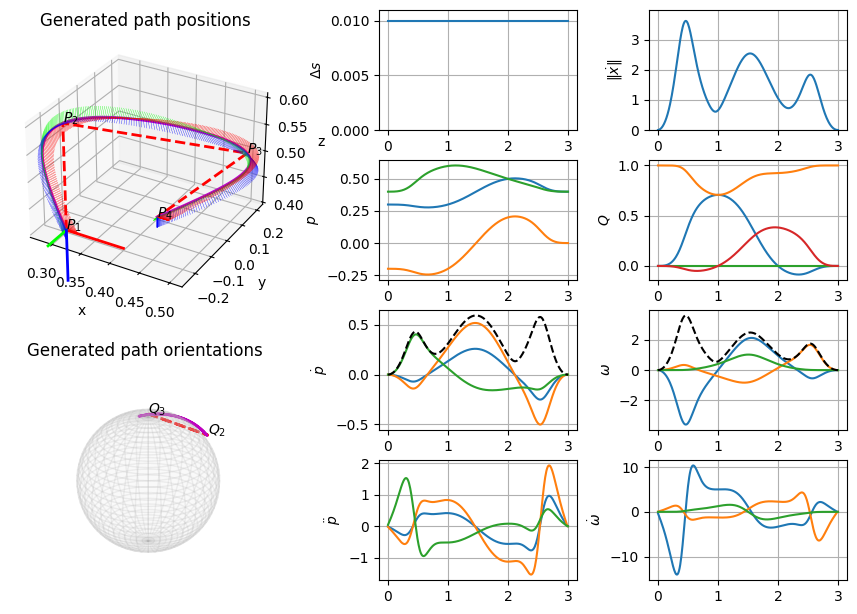

In [21]:
tmax = 3.0
dt = 0.01
sp = np.linspace(0.0, tmax, N)
c = sp
sigma2 = np.diff(c) ** 2
sigma2 = np.hstack([sigma2, sigma2[-1]])
init_cond = np.zeros((4, points.shape[1]))  # initial and final vel and acc
coff = 0.05  # additional kernels offset
sfac = 3  # sigma fac for aux RBF
t = np.arange(0.0, sp[-1] + dt, dt)
RBF = encodeRBF(sp, points, N=N, c=c, sigma2=sigma2 * 0.6**2, bc=init_cond, coff=coff, sfac=sfac)
xtr = decodeCartesianRBF(t, RBF)

_ = plotcpath(t, xtr, points=points)


first we execute motion using generated trajectory

In [22]:
r.JMove(r.q_home, 1)
r.CPath(xtr, tmax)

0

Then we use RBF encoded path (we perform motion forward and backward alog path)

In [23]:
r.JMove(r.q_home, 1)
r.CRBFPath(RBF, tmax)
r.CRBFPath(RBF, tmax, direction="Backward")


0

> ⚠️ Note: If the robot pose is not close to the initial path pose, then the robot is first moved to the initial path pose.

### Object and task space motion

To make motion programming easier we have defined additional methods for motion in commonly used task spaces (Tool And Object): 

| Task-space | Commands                                                     |
| ---------- | ------------------------------------------------------------ |
| Tool       | `TMove`, `TLine`                                             |
| Object     | `OMove`, `OMoveFor`, `OApproach`, `OLine`, `OLineFor`, `OArc`, `OPath`, `ORBFPath` |

These methods have the same optional parameters as listed before (if they are appropriate, of course). 


> Note that the Tool CS is attached to the robot end-effector. On the other side, the origin and orientation of the Object CS frame can be defined by user. In the next example we define new Object CS and move to the origin. 

First we define object frame (Marker shows the origin of object frame)

In [24]:
T1 = rp2t(rot_y(3 * np.pi / 4, out="R") @ rot_z(np.pi, out="R"), [0.4, 0.0, 0.7])
r.SetObject(T1)
print(r.GetObject())
r.SetMocapPose("Target",T1)

[[ 0.7071  0.0000  0.7071  0.4000]
 [ 0.0000 -1.0000  0.0000  0.0000]
 [ 0.7071  0.0000 -0.7071  0.7000]
 [ 0.0000  0.0000  0.0000  1.0000]]


Then we can define the movement in the object frame. In the following example, the three motion commands specify the same motion.

In [25]:
r.JMove(r.q_home)
r.OMove(np.eye(4), t=1)

r.JMove(r.q_home)
r.CMove(np.eye(4), t=1, task_space="Object")

r.JMove(r.q_home)
r.CMove(T1, t=1)

0

# Control strategies

All high-level motion commands use in the loop low-level methods, which actually send the commanded positions, velocities and torques to the robot controller. Which low level method is used, depends on the control strategy used. 

In general, the strategies are grouped in joint and task space strategies:

| Space | Strategies                                                   |
| ----- | ------------------------------------------------------------ |
| Joint | `'JointPosition'`, `'JointVelocity'`, `'JointImpedance'`     |
| Task  | `'CartesianPose'`, `'CartesianVelocity'`, `'CartesianImpedance'` |

However, which can be applied depends on the target robot system. For all simulation targets only `'JointPosition'` strategy can be used (actually, the strategy can not be changed). On the other side, if the target is a real robot, then strategies can be selected if a corresponding controller is implemented on the target controller. We can get, set and verify current strategy using commands:

| Method                      | Description                             |
| --------------------------- | --------------------------------------- |
| `r.GetStrategy()`    | Get control strategy                    |
| `r.SetStrategy(strategy)`     | Set current control strategy            |
| `r.isStrategy(strategy)` | Check if strategy is active             |
| `r.AvailableStrategies()`       | List of all available control strategies |

To check available strategies, use

In [26]:
r.AvailableStrategies()

['JointPosition']

To get the current selected strategy use:

In [27]:
r.GetStrategy()

'JointPosition'

To change it use

```python
r.SetStrategy("JointImpedance")
```

and to verify it


In [28]:
r.isStrategy("JointImpedance")

False

## Robot compliance 

If one of the impedance control strategies is selected, then we can get or set the stiffness (compliance) of the robot using methods

| Method                             | Description                               |
| ---------------------------------- | ----------------------------------------- |
| `val=GetJointStiffness`            | Get current joint stiffness               |
| `SetJointStiffness(stiffness)`     | Set joint stiffness                       |
| `val=GetJointDamping`              | Get current joint damping                 |
| `SetJointDamping(damping)`         | Set joint damping                         |
| `SetJointSoft(softness)`           | Set stiffness level: 0:compliant; 1:stiff |
| `SetJointCompliant`                | Sets zero joint stiffness                 |
| `SetJointStiff`                    | Sets maximal joint stiffness              |
| `val=GetCartesianStiffness`        | Get current cartesian stiffness           |
| `SetCartesianStiffness(stiffness)` | Set cartesian stiffness                   |
| `val=GetCartesianDamping`          | Get current cartesian damping             |
| `SetCartesianDamping(damping)`     | Set cartesian damping                     |
| `SetCartesianSoft(softness)`       | Set stiffness level: 0:compliant; 1:stiff |
| `SetCartesianCompliant`            | Sets zero Cartesian stiffness             |
| `SetCartesianStiff`                | Sets maximal Cartesian stiffness          |

Note that the stiffness and damping values depend on the particular implementation of impedance controllers on robots and that in some of the robot class implementations additional methods related to compliance are available. 

Some of the above method have optional parameters. One of the important options is `'HoldPose'` used for example in `SetJointStiffness` method

| Option       | Values          | Comment                                                      |
| ------------ | --------------- | ------------------------------------------------------------ |
| `hold_pose` | `True`, `False` | Value `True` means that the robot holds its position when it becomes more stiff. Value `False` means that stiffness will increase slowly to prevent sudden movements of the robot. |



> The stiffnes and damping parameters are used when the selected target controller is impedance controller, e.g. `'JointImpedance'` or `'CartesianImpedance'`.



## Low-level joint movement method

Regardless of the selected control strategy, joint motion is executed using the following low-level method

| Method                    | Description                          |
| ------------------------- | ------------------------------------ |
| `r.GoTo_q(q, qdot=None, trq=None, wait=None)` | Direct joint motion command          |
| `r.GoToActual()`              | Move to actual configuration in 1 sec |

which sends to the target controller the desired positions, desired velocities and additional joint torques. This method is called by the high-level motion methods periodically at frequency defined by the object property `r.tsamp`. Sampling time can be changed by using method

| Method            | Description       |
| ----------------- | ----------------- |
| `r.SetTsamp(tsamp)` | Set sampling time |

In most cases `tsamp` should not be less than 0.01ms. When GoTo_q is used directly, we have to set the input parameter `wait` to 0 or `tsamp`, except when want to allow the target controller to reach the desired state.

## Low-level task-space movement methods 

When using task-space movement, the situation is slightly different. Namely, the low-level motion method depends on the control strategy used on the target platform. Therefore, all high-level task-space movement methods call an intermediate method

| Method               | Description         |
| -------------------- | ------------------- |
| `r.GoTo_T(x, v=None, FT=None, ...)` | Move to task pose x |

which selects the corresponding low-level method based on current control strategy and implemented target controller. This method allows also to pass options from the high-level methods to the low-level methods.

| Method                | Description                                                  |
| --------------------- | ------------------------------------------------------------ |
| `r.GoTo_X(x, v=None, FT=None, ...)` | Move to task pose x and v using task space controller |
| `r.GoTo_TC(x, v=None, FT=None, ...)` | Move to task pose x and v using joint space position kinematic controller |

### Using redundancy

The master robot class provides a sophisticated kinematic controller `GoTo_TC` which allows task-space control of redundant robots. 

Method `GoTo_T` uses `GoTo_TC` whenever the target does not support task-space control. The kinematic controller implemented in `GoTo_TC` method uses a lot of parameters, which are passed as `options`:

| Option            | Values                                                       | Comment                                                      |
| ----------------- | ------------------------------------------------------------ | ------------------------------------------------------------ |
| `task_space`     | `"World"`, `"Robot"`, `"Object"`                             | Task-space of the input pose `x` and options `x_opt` and `v_ns` |
| `wait`          | `tsamp`                                                      | Maximal wait time in final position                          |
| `pos_err`        | `0`                                                        | Maximal task position error in final position                |
| `ori_err`        | `0`                                                        | Maximal task orientation error in final position             |
| `task_DOF`         | `[1, 1, 1, 1, 1, 1]`                                              | Selection of DOF in task-space (1: included in task-space)   |
| `task_cont_space` | `"World"`, `"Robot"`, `"Tool"`, `"Object"`                   | Task-space for the controller (used to align task DOF)       |
| `null_space_task` | `"None"`, `"Manipulability"`, `"JointLimits"`, `"ConfOptimization"`, `"PoseOptimization"`, `"TrackPath"`, `"TaskVelocity"`, `"JointVelocity"` | Secondary task used in redundancy resolution control         |
| `q_opt`         | `q`                                                          | Optimal joint configuration (used for `'ConfOptimization'`)  |
| `x_opt`         | `x_opt`                                                      | Optimal pose (osed for `'PoseOptimization'`)                 |
| `v_ns`          | `v_ns`                                                       | Task velocity for NS (used for `'TaskVelocity'`)             |
| `qdot_ns`          | `qdot_ns`                                                       | Joint velocity for NS            |
| `x_opt`          | `x_opt`                                                       | Optimal end-effector pose for NS            |
| `Kp`            | `10`                                                         | Task-space position gain                                     |
| `Kff`           | `1`                                                          | Task-space velocity feedforward gain                         |
| `Kns`           | `10`                                                         | Null-space gain                                              |
| `vel_fac`           | `1`                                                         | Velocity scaling factor for each joint                                              |


> Note that these options have to be defined in high-level motion commands and then they are passed to the `GoTo_TC`.

An example of using functional redundancy is

In [29]:
print("Initial pose: ", r.x) 
r.CMoveFor([0.0, 0.3, 0.0], 2)
r.CMoveFor([0.0, -0.3, 0.0], 2, task_DOF=np.array([1, 1, 1, 0, 0, 0]))
print("Final pose  : ", r.x) 

Initial pose:  [ 0.3993  0.0001  0.6930  0.0000 -0.9275 -0.0001 -0.3737]
Final pose  :  [ 0.4008  0.0000  0.6963 -0.0677 -0.9313 -0.3211 -0.1580]


where the robot task-space in the second movement includes only position of the end-effector. Consequently, the final orientation is not the same as the initial.

# Checks during motion

RBS Toolbox provides utilities to perform actions during robot motion, which can influence the execution of the commanded motion. 

First we have to prepare a callback function, which will be called in each sample of trajectory execution. For example, if we wan to push into an object the robot until a specified force is achieved the call back function can be like this


In [30]:
def check_fz_tool(robot):
    # Check force in object space z-axis
    if robot is None:
        return False

    FT = robot.GetFT()
    p = robot.GetPos()

    robot.User.Test.i += 1
    robot.User.Test.F.append(FT[2])
    robot.User.Test.p.append(p[0])

    return FT[2] > robot.User.Test.Fmax

Here, the output status changes when the external force exceeds the maximal value. In this example we also capture the position and force in desired direction.

> Note that the only input parameter has to be the `robot` object and all additional parameters have to be defined in the object's user property `robot.User`.  Next, the output variable interrupts the motion execution if it's value is not 0.

> The callback function has to have short execution time so that the overall execution time in one step is less the the selected sampling time.

This callback function is then applied to the high-level motion method in the following way

In [31]:
from robotblockset.tools import _struct

r.User = _struct()
r.User.Test = _struct()
r.User.Test.i = 0
r.User.Test.Fmax = 30
r.User.Test.F = []
r.User.Test.p = []
r.SetMotionCheckCallback(check_fz_tool)

The robot is commanded to move toward the object and when the maximal force is reached, motion is aborted and the robot moves back. 

In [32]:
xA = map_pose(R=rot_z(np.pi, out="R") @ rot_y(-np.pi / 2, out="R"), p=[0.7, 0., 0.7])
r.JMove(r.q_home)
r.CMove(xA)
r.Wait(1)
r.EnableMotionCheck()
if r.TMove([0.0, 0.0, 0.1], 5, traj="line") == 0:
    r.Message("Maximal force NOT reached", 1)
else:
    r.Message("Maximal force reached", 1)
r.DisableMotionCheck()
r.CMove(xA, 1)

[RBS_WARN] [1774247421.141962528] [panda_PyMuJoCo]: Motion check stopped motion
[RBS_INFO] [07:30:21] [panda_PyMuJoCo]: Maximal force reached


0

The captured forces during motion are

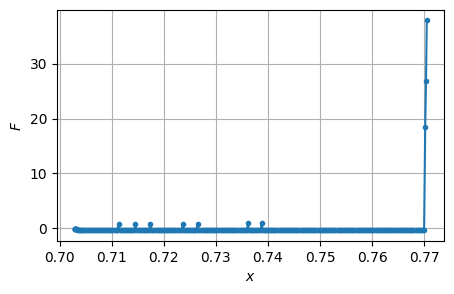

In [33]:
fig, ax = plt.subplots(1, 1, num=1, figsize=(5, 3))
ax.plot(r.User.Test.p, r.User.Test.F, ".-")
ax.grid()
ax.set_xlabel("$x$")
_ = ax.set_ylabel("$F$")

# Capturing robot motion

Often it necessary to capture some robot states for later analysis. RBS Toolbox provides methods  to capture different variables during robot motion. 

| Method                    | Description                                                  |
| ------------------------- | ------------------------------------------------------------ |
| `r.Update()`                  | Update robot states (using `r.GetState()`) and calls callback function |
| `r.GetUpdateStatus()`    | Returns Update calling flag                                  |
| `r.EnableUpdate()`            | Enables calling Update                                       |
| `r.DisableUpdate()`           | Disables calling Update                                      |
| `r.SetCaptureCallback(fun)` | Define function to capture desired variables                 |
| `r.StartCapture()`            | Start calling capturing function                             |
| `r.StopCapture()`             | Stop calling capturing function                              |
| `r.SetUserData(data)`       | Set value of custom variable, which can be captured          |
| `r.GetUserdata()`        | Get value of custom variable                                 |

Low-level motion methods call the `Update` method, which updates states by calling basic method `r.GetState()` and when capturing call back is set and enabled, it calls a user defined callback function. The user has to prepare a callback function and assign it to the `Update` method with`SetCaptureCallback` method . 

Before starting capture, it is necessary to initialize capturing. For that, a capturing function has to be defined. 

In [34]:
it = 0
def CaptureRobot(r):
    global it, tt, trob, qt, rqt, qdt, rqdt, xt, vt, rxt, rvt, mt, xtw, vtw, rxtw, rvtw, rrxtw, rrvtw, rTbt, tc, frames, tframes, last_time, framerate
    if it == 0:
        tt = np.array(r.t)
        trob = r._robottime
        qt = r._actual.q
        qdt = r._actual.qdot
        rqt = r._command.q
        rqdt = r._command.qdot
        xt = r._actual.x
        vt = r._actual.v
        rxt = r._command.x
        rvt = r._command.v
        mt = r._command.mode
    else:
        tt = np.vstack((tt, r.t))
        trob = np.vstack((trob, r._robottime))
        qt = np.vstack((qt, r._actual.q))
        qdt = np.vstack((qdt, r._actual.qdot))
        rqt = np.vstack((rqt, r._command.q))
        rqdt = np.vstack((rqdt, r._command.qdot))
        xt = np.vstack((xt, r._actual.x))
        vt = np.vstack((vt, r._actual.v))
        rxt = np.vstack((rxt, r._command.x))
        rvt = np.vstack((rvt, r._command.v))
        mt = np.vstack((mt, r._command.mode))
    it += 1

Then capturing can be enabled and disabled  by using methods `StartCapture` and `StopCapture`.

> ℹ️**Note:** If you do not want to append captured data to previous data, it is a good practice to set `it=0` and use `ResetTime` befor stating capture.

In [35]:
r.JMove(r.q_home)
r.Wait(2)

r.SetCaptureCallback(CaptureRobot)
r.ResetTime()
it = 0
r.StartCapture()
r.CMoveFor([0.1, -0.2, 0], t=2)
r.Wait(1)
r.JMove(r.q_home,2)
r.StopCapture()

> Note: Capturing function is called also during `Wait`.

The results can then be plotted.

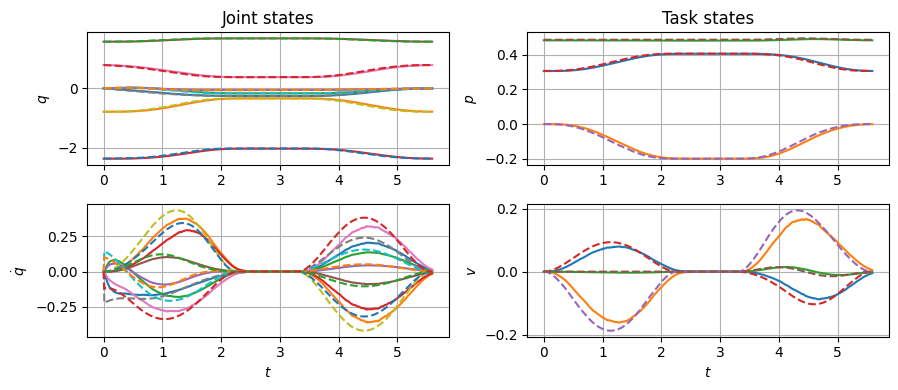

In [36]:
fig, ax = plt.subplots(2, 2, num=1, figsize=(9, 4))
ax = ax.flatten()
ax[0].plot(tt, qt, "-")
ax[0].plot(tt, rqt, "--")
ax[0].grid()
ax[0].set_ylabel("$q$")
ax[0].set_title("Joint states")
ax[2].plot(tt, qdt, "-")
ax[2].plot(tt, rqdt, "--")
ax[2].grid()
ax[2].set_ylabel("$\\dot q$")
ax[2].set_xlabel("$t$")

ax[1].plot(tt, xt[:, :3], "-")
ax[1].plot(tt, rxt[:, :3], "--")
ax[1].grid()
ax[1].set_ylabel("$p$")
ax[1].set_title("Task states")
ax[3].plot(tt, vt[:, :3], "-")
ax[3].plot(tt, rvt[:, :3], "--")
ax[3].grid()
ax[3].set_ylabel("$v$")
ax[3].set_xlabel("$t$")
plt.tight_layout()

# Utility methods

In RBS Toolbox, there are several utility methods.

| Method | Description |
| --- | --- |
| `x = r.DKin(q, out="x", task_space="Robot")` | Direct kinematics |
| `path = r.DKinPath(path_q, out="x")` | Direct kinematics along path |
| `q, status = r.IKin(T, q0=None, max_iterations=1000, pos_err=None, ori_err=None, task_space=None, task_DOF=None, ...)` | Numeric iterative inverse kinematics solution |
| `q_path, status = r.IKinPath(path_T, q0, max_iterations=100, pos_err=None, ori_err=None, task_space=None, task_DOF=None, ...)` | Numeric iterative inverse kinematics solution along path |
| `J = r.Jacobi(q, tcp=None, task_space="Robot")` | Calculates the Jacobian matrix from the kinematic model |
| `idx = r.Manipulability(q, task_space="Robot", task_DOF=None)` | Manipulability measure |
| `d = r.JointDistance(q, state="Actual")` | Distance between current position and q |
| `d = r.TaskDistance(T, out="x", task_space="World", state="Actual", kinematics="Calculated")` | Distance between current position and T |
| `stat = r.CheckJointLimits(q)` | Check if q in joint range |
| `dq, dq_low, dq_up = r.DistToJointLimits(q=None)` | Calculate distance to joint limits |
| `r.ResetCurrentTarget(do_move=False)` | Resets current commanded values to actual |
| `r.Wait(t, dt=None)` | Wait and update states while waiting |
| `r.WaitUntilStopped(eps=1e-3)` | Wait as long as robot is not stopped |
| `r.WaitUntilDone(timeout=None)` | Blocks execution until the motion completion or an optional timeout occurs. |
| `r.ResetTime()` | Resets the time |
| `r.Message(msg, verb=0)` | Show messages |
| `r.WarningMessage(msg)` | Show warning |

If for some reason, we want to set the reference values to current actual values, we can use

In [37]:
r.ResetCurrentTarget()

0

We can get the distance between the current position and a target.

In [38]:
r.JMove(r.q_home, t=1)
x2 = r.q
r.CMoveFor([0, 0.3, 0], t=1)

dist = r.JointDistance(r.q_home)
print("Distance between joint configurations: ", dist)

xdist = r.TaskDistance(x2)
print("Distance between task poses: ", xdist)


Distance between joint configurations:  [-0.0394 -0.2731 -0.5590 -0.2652 -0.2624 -0.0634 -0.5182]
Distance between task poses:  [-0.3062 -1.0785 -0.4829 -2.5233  0.8307 -1.6651]


We can wait or wait until robot is stopped.

In [39]:
r.Wait(1)
r.WaitUntilStopped(eps=1e-6)  # until norm(qdot) < eps

We can print messages or warnings.

In [40]:
r.Message("Task finished")
r.WarningMessage("Gripper not opened")

[RBS_INFO] [07:30:37] [panda_PyMuJoCo]: Task finished
[RBS_WARN] [1774247437.526340008] [panda_PyMuJoCo]: Gripper not opened


# Force sensors

Force/torque sensing is handled by `force_torque_sensor` objects from `sensors.py`, which support robot attachment, averaging, zeroing, offsets, and load compensation. The `robot` interface in `robots.py` is used to attach the sensor, define its frame, configure load data, and read the measured wrench in different frames and output forms.

| Method | Description |
| --- | --- |
| `SetFTSensor(FTsensor=None)` | Attaches an FT sensor to the robot, or detaches the current sensor when `None` is passed. |
| `GetFTSensor()` | Returns the current FT sensor object together with its name. |
| `SetFTSensorFrame(x)` | Sets the FT sensor frame relative to the robot flange from a pose, rotation, or homogeneous transform. |
| `GetFTSensorFrame(out=None)` | Returns the configured FT sensor frame in the requested pose format. |
| `GetFTSensorPose(out=None, task_space=None)` | Returns the current FT sensor pose in the selected task space and output form. |
| `SetFTSensorLoad(load=None, mass=None, COM=None, inertia=None, offset=None)` | Sets or updates the load model associated with the FT sensor for compensation. |
| `GetFTSensorLoad()` | Returns the load currently assigned to the FT sensor. |
| `GetFT(out=None, source=None, task_space="FTFrame", kinematics=None, avg_time=0, user_frame=None, refresh=None)` | Reads force/torque data from the robot or external sensor and returns it as a wrench, force, or torque in the requested frame. |

`GetFT(...)` first computes a 6D wrench in the robot FT frame and only then converts it to the requested output. The returned values depend on the arguments as follows:

- `source="External"`: reads `self.FTSensor.GetFT(avg_time=avg_time)`, so `avg_time` controls sensor-side averaging; if an external sensor load is defined, gravity compensation based on sensor load mass and COM is subtracted before frame conversion.
- `source="Robot"`, `kinematics="Robot"`: uses the robot's measured wrench `self._actual.FT`; gravity compensation is computed from the robot load model `self.Load` and transformed into `FTFrame`.
- `source="Robot"`, `kinematics="Calculated"`: estimates the wrench from external joint torques with `pinv(J^T) @ self._actual.trqExt`, then transforms it from TCP to `FTFrame`.
- `task_space`: after the wrench is available in `FTFrame`, it is transformed to `World`, `Object`, `Robot`, `Tool`/`TCP`, `FTFrame`, or a provided `User` frame.
- `out`: selects the returned part of the transformed value: full 6D wrench (`"Wrench"`), only force (`"Force"`, first 3 values), or only torque (`"Torque"`, last 3 values).
- `refresh`: if enabled, updates the robot state before reading the wrench; for `task_space="User"`, `user_frame` must be provided.

# Transformations

Robotblockset provides transformation helpers for converting poses, orientations, positions, twists, wrenches, and Jacobians between the main geometric frames used by the robot model. These methods are used when commands or measured quantities are expressed in a different frame than the controller or user wants to work in. The explicit frame-conversion methods in [`robots.py`](/d:/Leon/Python/RBS/robotblockset/robots.py) currently cover mappings between `World`, robot base (`Robot`), `Object`, and robot-mounted `Camera` frames.

| Method | Description |
| --- | --- |
| `r.BaseToWorld(x, typ=None)` | Transform a quantity from the robot base frame to the world frame. |
| `r.WorldToBase(x, typ=None)` | Transform a quantity from the world frame to the robot base frame. |
| `r.ObjectToWorld(x)` | Transform a quantity from the object frame to the world frame. |
| `r.WorldToObject(x)` | Transform a quantity from the world frame to the object frame. |
| `r.CameraToBase(x, typ=None, kinematics=None, state=None, refresh=None)` | Transform a quantity from the camera frame to the robot base frame using the current flange pose and `CameraFrame`. |
| `r.BaseToCamera(x, typ=None, kinematics=None, state=None, refresh=None)` | Transform a quantity from the robot base frame to the camera frame using the current flange pose and `CameraFrame`. |

Argument `typ` can be used if the quantity is a velocity or wrench. If `typ="Twist"`, the relevant frame motion is considered in velocity transformation.


# Grippers

Gripper support is defined in `grippers.py` through the base `gripper` interface and the `dummygripper` example implementation. A gripper can be attached to a robot, commanded to move to a width, opened, closed, or used for grasping, while also exposing simple state queries.

| Method | Description |
| --- | --- |
| `Move(width, **kwargs)` | Abstract width command that concrete grippers implement to move to the requested opening. |
| `Open(**kwargs)` | Opens the gripper to its maximum width and updates the internal state to opened on success. |
| `Close(**kwargs)` | Closes the gripper to width `0` and updates the internal state to closed on success. |
| `Grasp(**kwargs)` | Closes around an object, optionally using `width` from `kwargs`, and marks the gripper as closed on success. |
| `Homing(**kwargs)` | Resets the gripper to an open state by calling `Open`; it enables `check=True` by default. |
| `isOpened()` | Returns `True` when the internal gripper state is opened. |
| `isClosed()` | Returns `True` when the internal gripper state is closed. |
| `GetState()` | Returns the current state string: `"Opened"`, `"Closed"`, or `"Undefined"`. |
| `AttachTo(robot)` | Attaches the gripper to a robot instance. |
| `Detach()` | Detaches the gripper from the currently attached robot. |
| `GetAttachedRobot()` | Returns the attached robot and its name, or `(None, "None")` if no robot is attached. |

Define gripper

Note that in MuJoCo, the scene of the gripper is the scene of the robot

In [41]:
from robotblockset.mujoco.grippers_pymujoco import panda_gripper

g = panda_gripper(scene=r.scene)

[RBS_INFO] [07:30:37] [Panda_Gripper_PyMuJoCo]: Gripper connected to PyMuJoCo


Open and close gripper

In [42]:
g.Open()
g.Close()

1

We attach gripper to robot

In [43]:
g.AttachTo(r)
print(f"Gripper is attached to robot: {g.GetAttachedRobot()[1]}")

Gripper is attached to robot: panda_PyMuJoCo


The `robot` class manages gripper attachment and the nominal gripper TCP used when tool poses are defined relative to the gripper. The main gripper-related methods from `robots.py` are:

| Method | Description |
| --- | --- |
| `SetGripper(gripper=None)` | Attaches a gripper to the robot, or detaches the current one when `None` is passed. |
| `GetGripper()` | Returns the current gripper object together with its name. |
| `SetTCP(tcp=None, frame="Gripper")` | Sets the robot TCP; with `frame="Gripper"` the given TCP is interpreted relative to `TCPGripper`. |
| `SetTCPGripper(tcp=None)` | Sets the nominal gripper TCP transformation relative to the robot flange. |
| `GetTCPGripper(out="T")` | Returns the nominal gripper TCP in the requested output format. |

and variables:

| Variable | Description |
| --- | --- |
| `Gripper` | The gripper object currently attached to the robot, or `None` if no gripper is assigned. |
| `TCPGripper` | The nominal gripper TCP transformation matrix relative to the flange. |
| `TCP` | The active robot tool center point; when `SetTCP(..., frame="Gripper")` is used it is computed from `TCPGripper`. |

The same as before can be done in this way

In [44]:
r.SetGripper(g)
print(f"Robot has attached gripper  : {r.GetGripper()[1]}")

Robot has attached gripper  : Panda_Gripper_PyMuJoCo


and the gripper can be controlled in this way:

In [45]:
r.Gripper.Open()
r.Gripper.Close()

1

# Cameras

The `robot` class can store a camera object and the calibrated camera frame. A camera object is attached with `SetCamera(camera)`, and the camera pose relative to the robot flange is defined with `SetCameraFrame(x)`. The camera frame can be provided as a homogeneous transform, pose, position, orientation, or rotation matrix, using the same spatial input conventions as TCP definitions.

| Method | Description |
| --- | --- |
| `SetCamera(camera=None)` | Attaches a camera to the robot, or detaches the current camera when `None` is passed. |
| `GetCamera()` | Returns the current camera object together with its name, or `[None, "None"]` if no camera is assigned. |
| `SetCameraFrame(x)` | Sets the camera frame relative to the robot flange from a pose, position, orientation, rotation matrix, or homogeneous transform. |
| `GetCameraFrame(out=None)` | Returns the configured camera frame in the requested output format, or `None` if it has not been set. |
| `CameraToBase(x, typ=None, kinematics=None, state=None, refresh=None)` | Transforms poses, positions, rotations, twists, wrenches, or transforms from the camera frame to the robot base frame. |
| `BaseToCamera(x, typ=None, kinematics=None, state=None, refresh=None)` | Transforms poses, positions, rotations, twists, wrenches, or transforms from the robot base frame to the camera frame. |

The camera pose in the robot base frame is computed from the current flange pose and `CameraFrame` as `Tflange @ CameraFrame`. `CameraToBase(...)` and `BaseToCamera(...)` therefore require `SetCameraFrame(...)` to be called first.


In [ ]:
# Example: camera frame 10 cm in front of the flange.
r.SetCameraFrame(map_pose(p=[0, 0, 0.10], out="T"))

point_in_camera = np.array([0.0, 0.0, 0.5])
point_in_base = r.CameraToBase(point_in_camera)
point_back_in_camera = r.BaseToCamera(point_in_base)

print("Camera frame:")
print(r.GetCameraFrame(out="T"))
print(f"Point in base: {point_in_base}")
print(f"Point back in camera: {point_back_in_camera}")


# Defaults

Class `_default` in [`robots.py`](/d:/Leon/Python/RBS/robotblockset/robots.py) stores the fallback values used when method arguments are omitted. These defaults define how Robotblockset interprets states and coordinate spaces, how trajectories and kinematic control are generated, which tolerances are used to stop motions, and what nominal motion limits are assumed for joint and Cartesian commands. They can be inspected and modified through `r._default`.

| Parameter | Description |
| --- | --- |
| `State` | Default state source for getters, typically `"Actual"` or `"Commanded"`. |
| `TaskSpace` | Default task coordinate system, for example `"World"`, `"Robot"`, `"Object"`, or `"Tool"`. |
| `TaskPoseForm` | Default representation used for task poses. |
| `TaskOriForm` | Default representation used for task orientations. |
| `TaskVelForm` | Default representation used for Cartesian velocities. |
| `TaskFTForm` | Default representation used for forces and torques. |
| `TaskErrForm` | Default representation used for task-space errors. |
| `Kinematics` | Selects whether robot-native or internally calculated kinematics are used. |
| `Refresh` | Controls whether state getters refresh robot state before returning values. |
| `TCPFrame` | Default frame in which TCP-related quantities are interpreted. |
| `Source` | Default source of configuration or model data, such as robot-side or external. |
| `Strategy` | Default motion/control strategy. |
| `TaskContSpace` | Default control space for task-space controllers. |
| `NullSpaceTask` | Default null-space objective used in redundant manipulator control. |
| `UseInternal` | Enables use of implementation-specific internal motion commands when supported. |
| `DampedPseudoInverseFactor` | Damping factor used in damped pseudo-inverse Jacobian calculations. |
| `RotDirShort` | If `True`, rotational moves prefer the shorter orientation path. |
| `Traj` | Default trajectory type for generated motions, for example polynomial or trapezoidal. |
| `TaskDOF` | Default active task-space degrees of freedom mask. |
| `VelocityScaling` | Global scaling factor applied to nominal motion velocity limits. |
| `MinJointDist` | Minimum joint-space distance required before a new joint move is executed. |
| `MinPosDist` | Minimum Cartesian position distance required before a new move is executed. |
| `MinOriDist` | Minimum orientation distance required before a new move is executed. |
| `PosErr` | Position error tolerance used to decide whether a Cartesian target has been reached. |
| `OriErr` | Orientation error tolerance used to decide whether a Cartesian target has been reached. |
| `AddedTrq` | Default additional joint torques added to commanded joint control inputs. |
| `AddedFT` | Default additional force/torque wrench added to Cartesian commands. |
| `Kp` | Proportional gain of the kinematic/task controller. |
| `Kff` | Feed-forward gain used in kinematic/task control. |
| `Kns` | Null-space gain used in redundant task control. |
| `Kns0` | Null-space gain used specifically for joint-limit handling. |
| `Wait` | Default wait time after motion commands complete. |
| `TCTimeout` | Default timeout for the task-space kinematic controller. |
| `UpdateTime` | Default maximum idle interval before state variables are refreshed. |
| `TrajSampTimeFac` | Factor used to choose sampling density for generated trajectories. |
| `JointVelocity` | Nominal default joint velocity limit used by internal joint moves. |
| `JointAcceleration` | Nominal default joint acceleration used by internal joint moves. |
| `JointDeceleration` | Nominal default joint deceleration used when stopping joint motion. |
| `TaskVelocity` | Nominal default Cartesian velocity limit used by task-space moves. |
| `TaskAcceleration` | Nominal default Cartesian acceleration used by task-space moves. |
| `TaskDeceleration` | Nominal default Cartesian deceleration used when stopping task-space motion. |

In [46]:
for attr in dir(r._default):
    if not attr.startswith("_"):
        x = eval(f"r._default.{attr}")
        print(f"{attr} = {x}")

AddedFT = [ 0.0000  0.0000  0.0000  0.0000  0.0000  0.0000]
AddedTrq = [ 0.0000  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000]
DampedPseudoInverseFactor = 0.0
JointAcceleration = 2.0
JointDeceleration = 2.0
JointVelocity = 1.0
Kff = 1
Kinematics = Robot
Kns = 1
Kns0 = 0.1
Kp = 10
MinJointDist = 0
MinOriDist = 0
MinPosDist = 0
NullSpaceTask = JointLimits
OriErr = 0.001
PosErr = 0.0001
Refresh = True
RotDirShort = True
Source = Robot
State = Actual
Strategy = JointPosition
TCPFrame = Gripper
TCTimeout = 0.5
TaskAcceleration = 1
TaskContSpace = Robot
TaskDOF = [ 1.0000  1.0000  1.0000  1.0000  1.0000  1.0000]
TaskDeceleration = 10
TaskErrForm = Task
TaskFTForm = Wrench
TaskOriForm = Quaternion
TaskPoseForm = Pose
TaskSpace = World
TaskVelForm = Twist
TaskVelocity = 0.25
Traj = poly
TrajSampTimeFac = 5
UpdateTime = 1.0
UseInternal = False
VelocityScaling = 1
Wait = 0
asdict = <bound method _struct.asdict of State: Actual
TaskSpace: World
TaskPoseForm: Pose
TaskOriForm: Quaternion
TaskVel